# MobileNetV2 Pretrained — NWPU-RESISC45
**Model 3 of 3** | ImageNet weights · ~3.4M params · Edge model · CE loss · Adam · Augment

## Imports

In [38]:
import time
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
import torchvision.models as models

In [39]:
# -------------------------------
# CONFIG
# -------------------------------
data_path  = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45"   # same as Models 1 & 2
MODEL_PATH = "mobilenetv2_best.pth"
TRAIN      = True   # Set False to skip training and load checkpoint

## Device Check

In [23]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

True
0
NVIDIA T1200 Laptop GPU
Using device: cuda


## Dataset Preparation

### 1. Transforms

Same ImageNet normalization stats as Models 1 & 2. MobileNetV2 is designed for 224×224 input.
Augmentations include flips and rotation — useful for satellite/aerial imagery.

In [24]:
def get_resisc45_transforms(img_size=224, augment=True):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]) if augment else transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_tf = transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_tf, val_tf

### 2. DataLoader Setup

In [25]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

    def __len__(self):
        return len(self.subset)

In [26]:
def get_dataloaders(data_root, img_size=224, batch_size=24):
    # Same batch size as Model 1 (scratch) — MobileNetV2 is lighter so you can go higher if needed

    train_tf, val_tf = get_resisc45_transforms(img_size)

    base_dataset = datasets.ImageFolder(root=data_root)

    n_total = len(base_dataset)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val

    # Same seed as Models 1 & 2 — ensures identical train/val/test splits
    train_ds, val_ds, test_ds = random_split(
        base_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )

    train_ds = TransformSubset(train_ds, train_tf)
    val_ds   = TransformSubset(val_ds, val_tf)
    test_ds  = TransformSubset(test_ds, val_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )

    return train_loader, val_loader, test_loader

## Architecture — MobileNetV2 Pretrained

MobileNetV2 uses **inverted residual blocks** with depthwise separable convolutions.
It has only ~3.4M parameters — roughly 3× lighter than ResNet18 — making it ideal for edge deployment.

We:
1. Load torchvision MobileNetV2 with **ImageNet pretrained weights**
2. Replace the final classifier for 45 classes
3. Train the full network end-to-end (MobileNetV2 is compact enough that full fine-tuning works well directly)

In [27]:
def build_mobilenetv2(num_classes: int = 45, dropout_p: float = 0.2) -> nn.Module:
    """
    Load torchvision MobileNetV2 with ImageNet pretrained weights.
    Replace the classifier head to output `num_classes` logits.

    MobileNetV2 classifier structure: [Dropout, Linear(1280 -> 1000)]
    We replace it with:               [Dropout, Linear(1280 -> num_classes)]
    """
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # The classifier is model.classifier = nn.Sequential(Dropout, Linear)
    in_features = model.classifier[1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )

    return model


def count_params(model: nn.Module):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters  : {total:,}")
    print(f"Trainable params  : {trainable:,}")
    print(f"Model size (FP32) : {total * 4 / 1024**2:.2f} MB")

## Training Functions

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(
            device,
            non_blocking=True,
            dtype=torch.float32
        )

        labels = labels.to(
            device,
            non_blocking=True
        )
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return {
        "loss": total_loss / total,
        "acc": correct / total
    }

### Evaluate

In [29]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return {"loss": total_loss / total, "acc": correct / total}

### Full Training Loop

MobileNetV2 trains end-to-end in a single phase (no freeze/unfreeze needed — the model is already compact).
Uses CE loss + Adam + cosine LR schedule, matching the diagram.

In [ ]:
def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 25,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    save_path: str = "mobilenetv2_best.pth",
    device_str: str = "auto",
):


    device = (
        torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if device_str == "auto"
        else torch.device(device_str)
    )

    print(f"Training on: {device}")

    model = model.to(device)


    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs
    )

    best_val_acc = 0.0
    patience_ctr = 0
    patience = 5

    history = []

    for epoch in range(1, num_epochs + 1):

        t0 = time.time()

        train_stats = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_stats = evaluate(
            model,
            val_loader,
            criterion,
            device
        )


        scheduler.step()
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']


        print(
            f"Epoch {epoch:3d}/{num_epochs}  "
            f"Train Loss: {train_stats['loss']:.4f} | "
            f"Train Acc: {train_stats['acc']:.4f} | "
            f"Val Loss: {val_stats['loss']:.4f} | "
            f"Val Acc: {val_stats['acc']:.4f} | "
            f"LR: {lr_now:.2e} | "
            f"{elapsed:.1f}s"
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_acc": train_stats["acc"],
            "val_loss": val_stats["loss"],
            "val_acc": val_stats["acc"],
            "lr": lr_now,
        })


        if val_stats['acc'] > best_val_acc:

            best_val_acc = val_stats['acc']

            patience_ctr = 0

            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_acc": best_val_acc,
            }, save_path)

            print(f"  ✅ New best saved: {best_val_acc:.4f}")

        else:
            patience_ctr += 1

            if patience_ctr >= patience:

                print(
                    f"\n Early stopping at epoch {epoch} "
                    f"(no improvement for {patience} epochs)"
                )

                break

    print(f"\nTraining complete. Best val acc: {best_val_acc:.4f}")

    return history

## Visualization Before Training

Shows class distribution and a preview batch (after transforms) before training starts.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


def visualize_before_training(data_root: str, train_loader: DataLoader, preview_count: int = 8):
    base_dataset = datasets.ImageFolder(root=data_root)
    class_names = base_dataset.classes
    class_counts = Counter(base_dataset.targets)

    plt.figure(figsize=(14, 4))
    plt.bar(range(len(class_names)), [class_counts[i] for i in range(len(class_names))])
    plt.title("Class Distribution (Full Dataset)")
    plt.xlabel("Class Index")
    plt.ylabel("Image Count")
    plt.tight_layout()
    plt.show()

    # Preview transformed training samples
    images, labels = next(iter(train_loader))
    images = images[:preview_count].cpu().numpy().transpose(0, 2, 3, 1)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    images = np.clip(images * std + mean, 0, 1)

    cols = min(4, preview_count)
    rows = int(np.ceil(preview_count / cols))
    plt.figure(figsize=(4 * cols, 3 * rows))
    for i in range(preview_count):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.suptitle("Pre-Training Sample Preview (With Augmentations)", y=1.02)
    plt.tight_layout()
    plt.show()

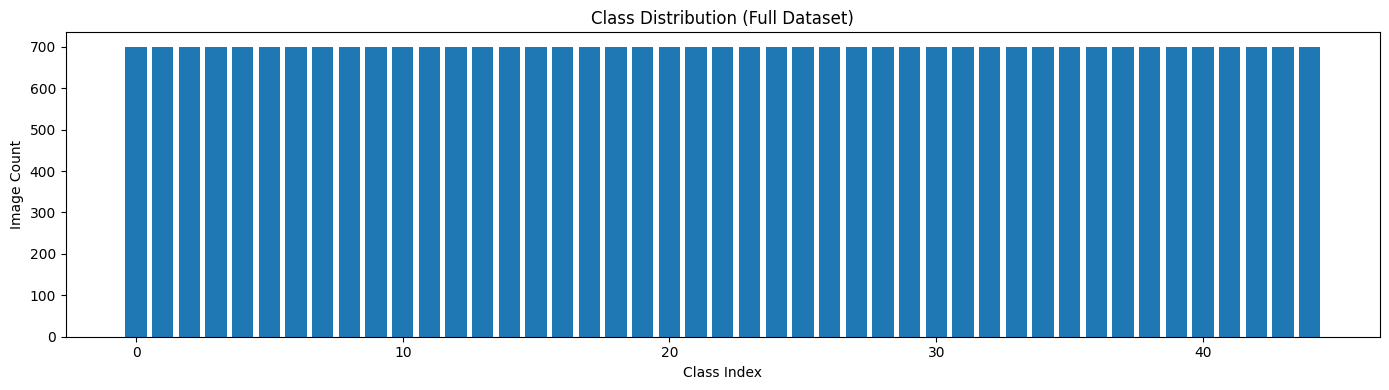

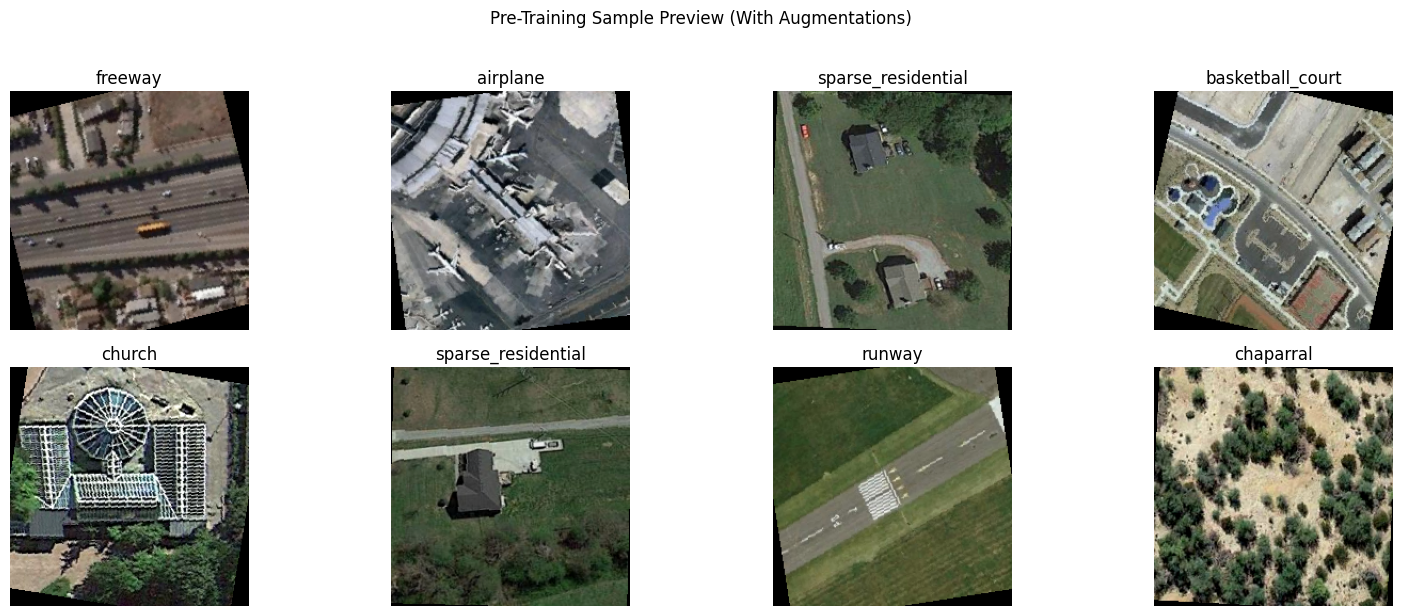

In [32]:

# -------------------------------
# VISUALIZATION BEFORE TRAINING
# -------------------------------
data_path  = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45"   # same as Models 1 & 2
TRAIN      = True 
if TRAIN:
    train_loader, val_loader, test_loader = get_dataloaders(data_path)
else:
    _, _, test_loader = get_dataloaders(data_path)
visualize_before_training(data_path, train_loader, preview_count=8)

In [33]:
# Class names from the loader, no path-based lookup needed
class_names = getattr(getattr(getattr(train_loader.dataset, "subset", None), "dataset", None), "classes", None)
if class_names is None:
    class_names = test_loader.dataset.subset.dataset.classes if hasattr(test_loader.dataset, "subset") else datasets.ImageFolder(root=data_path).classes

# -------------------------------
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

Class names: ['airplane', 'airport', 'baseball_diamond', 'basketball_court', 'beach', 'bridge', 'chaparral', 'church', 'circular_farmland', 'cloud', 'commercial_area', 'dense_residential', 'desert', 'forest', 'freeway', 'golf_course', 'ground_track_field', 'harbor', 'industrial_area', 'intersection', 'island', 'lake', 'meadow', 'medium_residential', 'mobile_home_park', 'mountain', 'overpass', 'palace', 'parking_lot', 'railway', 'railway_station', 'rectangular_farmland', 'river', 'roundabout', 'runway', 'sea_ice', 'ship', 'snowberg', 'sparse_residential', 'stadium', 'storage_tank', 'tennis_court', 'terrace', 'thermal_power_station', 'wetland']
Number of classes: 45


## Run

In [ ]:
# -------------------------------
# CONFIG
# -------------------------------
data_path  = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45"   # same as Models 1 & 2
MODEL_PATH = "mobilenetv2_best.pth"
TRAIN      = True   # Set False to skip training and load checkpoint

# -------------------------------
# MODEL
# -------------------------------
model = build_mobilenetv2(num_classes=45, dropout_p=0.2)
print("=== MobileNetV2 — Model Summary ===")
count_params(model)

# -------------------------------
# DATA
# -------------------------------
if TRAIN:
    train_loader, val_loader, test_loader = get_dataloaders(data_path)
else:
    _, _, test_loader = get_dataloaders(data_path)

# Sanity check
test_batch_img, test_batch_lbl = next(iter(test_loader))
test_batch_img = test_batch_img.to(device)
print(f"Test batch on device: {test_batch_img.device}")
print(f"Batch shape: {test_batch_img.shape}")


# -------------------------------
# TRAIN OR LOAD
# -------------------------------
if TRAIN:
    print("\nStarting training...\n")
    history = train(
        model,
        train_loader,
        val_loader,
        num_epochs=25,
        lr=1e-4,
        save_path=MODEL_PATH
    )
    model.eval()
else:
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Checkpoint not found: {MODEL_PATH}")

    print("\nLoading trained model...\n")
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model.to(device)
    model.eval()

print("\nModel is ready ✔️")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\DELL/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:04<00:00, 2.85MB/s]


=== MobileNetV2 — Model Summary ===
Total parameters  : 2,281,517
Trainable params  : 2,281,517
Model size (FP32) : 8.70 MB
Test batch on device: cuda:0
Batch shape: torch.Size([24, 3, 224, 224])

Starting training...

Training on: cuda
Epoch   1/25  Train Loss: 1.4829 | Train Acc: 0.7661 | Val Loss: 1.0746 | Val Acc: 0.8904 | LR: 9.96e-05 | 285.9s
  ✅ New best saved: 0.8904
Epoch   2/25  Train Loss: 1.0548 | Train Acc: 0.8942 | Val Loss: 0.9944 | Val Acc: 0.9168 | LR: 9.84e-05 | 466.0s
  ✅ New best saved: 0.9168
Epoch   3/25  Train Loss: 0.9839 | Train Acc: 0.9180 | Val Loss: 0.9467 | Val Acc: 0.9276 | LR: 9.65e-05 | 373.3s
  ✅ New best saved: 0.9276
Epoch   4/25  Train Loss: 0.9399 | Train Acc: 0.9315 | Val Loss: 0.9454 | Val Acc: 0.9280 | LR: 9.38e-05 | 342.4s
  ✅ New best saved: 0.9280
Epoch   5/25  Train Loss: 0.9071 | Train Acc: 0.9439 | Val Loss: 0.9421 | Val Acc: 0.9312 | LR: 9.05e-05 | 300.5s
  ✅ New best saved: 0.9312
Epoch   6/25  Train Loss: 0.8772 | Train Acc: 0.9534 | Val

## Evaluation (Model Metrics)

In [11]:
def print_model_metrics(model: nn.Module, img_size: int = 224):
    device = next(model.parameters()).device

    stats = summary(
        model,
        input_size=(1, 3, img_size, img_size),
        device=device,
        verbose=0,
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = total_params * 4 / (1024 ** 2)

    print(f"\n{'='*50}")
    print(f"  Total parameters  : {total_params:,}")
    print(f"  Trainable params  : {trainable:,}")
    print(f"  Model size (FP32) : {size_mb:.2f} MB")
    print(f"  Total FLOPs       : {stats.total_mult_adds / 1e9:.2f} GFLOPs")
    print(f"{'='*50}\n")

    print("Edge deployment guidance:")
    print("  - High-end phone (Snapdragon / Apple A-series): ~5–10 ms/image  → Excellent")
    print("  - Laptop CPU (no GPU):                         ~20–60 ms/image  → Excellent")
    print("  - Raspberry Pi 4:                              ~80–150 ms/image → Good")
    print("  - Microcontrollers:                            still too heavy, use MobileNetV3-Small")
    print(f"\nAfter INT8 quantization:")
    print(f"  - Estimated size: ~{size_mb/4:.2f} MB")
    print(f"  - ~2–3× faster CPU inference")
    print(f"  - Minimal accuracy drop (typically <1%)\n")

In [ ]:
# Load best checkpoint for final evaluation
checkpoint = torch.load(MODEL_PATH, weights_only=False)
model = build_mobilenetv2(num_classes=45)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

# -------------------------------
# TEST EVALUATION
# -------------------------------
test_stats = evaluate(model, test_loader, criterion, device)

print("\n=== TEST RESULTS ===")
print(f"Test Accuracy: {test_stats['acc']:.4f}")
print(f"Test Loss    : {test_stats['loss']:.4f}")

# -------------------------------
# MODEL METRICS
# -------------------------------
print("\n=== MODEL METRICS (FP32) ===")
print_model_metrics(model)


=== TEST RESULTS ===
Test Accuracy: 0.9534
Test Loss    : 0.2656

=== MODEL METRICS (FP32) ===

  Total parameters  : 2,281,517
  Trainable params  : 2,281,517
  Model size (FP32) : 8.70 MB
  Total FLOPs       : 0.30 GFLOPs

Edge deployment guidance:
  - High-end phone (Snapdragon / Apple A-series): ~5–10 ms/image  → Excellent
  - Laptop CPU (no GPU):                         ~20–60 ms/image  → Excellent
  - Raspberry Pi 4:                              ~80–150 ms/image → Good
  - Microcontrollers:                            still too heavy, use MobileNetV3-Small

After INT8 quantization:
  - Estimated size: ~2.18 MB
  - ~2–3× faster CPU inference
  - Minimal accuracy drop (typically <1%)



In [36]:
# -------------------------------
# REBUILD MODEL
# -------------------------------
model = build_mobilenetv2(num_classes=45)

# -------------------------------
# LOAD CHECKPOINT
# -------------------------------
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint["model_state"])

# -------------------------------
# MOVE TO DEVICE
# -------------------------------
model = model.to(device)
model.eval()

print("Model loaded successfully ✔️")

Model loaded successfully ✔️


## Quantize + ONNX Export

In [13]:
def quantize_dynamic(model: nn.Module, save_path: str = "mobilenetv2_dynamic_int8.pth") -> nn.Module:
    """
    Dynamic INT8 quantization:
    - No calibration required
    - Quantizes Linear layers only
    - Fast to apply, good CPU speedup
    """
    model_cpu = model.cpu().eval()

    quantized = torch.quantization.quantize_dynamic(
        model_cpu,
        qconfig_spec={nn.Linear},
        dtype=torch.qint8,
    )

    torch.save(quantized.state_dict(), save_path)
    print(f"Dynamic-quantized model saved -> {save_path}")
    return quantized


def quantize_static(
    model: nn.Module,
    calibration_loader: DataLoader,
    save_path: str = "mobilenetv2_static_int8.pth",
) -> nn.Module:
    """
    Static INT8 quantization (PTQ as per diagram):
    - Calibrates Conv + Linear layers
    - Better size & latency gains than dynamic
    - FP32 → INT8, ~4x size reduction
    """
    model_cpu = model.cpu().eval()
    model_cpu.qconfig = torch.quantization.get_default_qconfig("x86")

    torch.quantization.prepare(model_cpu, inplace=True)

    print("Calibrating for static quantization...")
    with torch.no_grad():
        for i, (images, _) in enumerate(calibration_loader):
            model_cpu(images)
            if i >= 10:
                break

    torch.quantization.convert(model_cpu, inplace=True)
    torch.save(model_cpu.state_dict(), save_path)
    print(f"Static-quantized model saved -> {save_path}")
    return model_cpu


def export_to_onnx(model, save_path="mobilenetv2.onnx", img_size=224, opset=17):
    model = model.cpu().eval()
    dummy_input = torch.randn(1, 3, img_size, img_size)

    torch.onnx.export(
        model,
        dummy_input,
        save_path,
        opset_version=opset,
        input_names=["image"],
        output_names=["logits"],
        dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
        do_constant_folding=True
    )
    print("ONNX exported:", save_path)


def validate_onnx(onnx_path: str, img_size: int = 224, num_classes: int = 45):
    import onnxruntime as ort
    import numpy as np

    session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    dummy = np.random.randn(1, 3, img_size, img_size).astype(np.float32)
    outputs = session.run(None, {"image": dummy})

    assert outputs[0].shape == (1, num_classes), \
        f"Unexpected output shape: {outputs[0].shape}"

    print(f"ONNX validation passed - output shape: {outputs[0].shape}")
    return outputs[0]

In [14]:
# -------------------------------
# QUANTIZATION (PTQ — matches diagram)
# -------------------------------
print("\nApplying dynamic quantization...\n")
q_model = quantize_dynamic(model)
print("\n=== MODEL METRICS (INT8) ===")
print_model_metrics(q_model)


Applying dynamic quantization...

Dynamic-quantized model saved -> mobilenetv2_dynamic_int8.pth

=== MODEL METRICS (INT8) ===

  Total parameters  : 2,223,872
  Trainable params  : 2,223,872
  Model size (FP32) : 8.48 MB
  Total FLOPs       : 0.30 GFLOPs

Edge deployment guidance:
  - High-end phone (Snapdragon / Apple A-series): ~5–10 ms/image  → Excellent
  - Laptop CPU (no GPU):                         ~20–60 ms/image  → Excellent
  - Raspberry Pi 4:                              ~80–150 ms/image → Good
  - Microcontrollers:                            still too heavy, use MobileNetV3-Small

After INT8 quantization:
  - Estimated size: ~2.12 MB
  - ~2–3× faster CPU inference
  - Minimal accuracy drop (typically <1%)



In [15]:
# -------------------------------
# ONNX EXPORT + VALIDATION
# -------------------------------
print("\nExporting to ONNX...\n")
export_to_onnx(model, "mobilenetv2.onnx")
validate_onnx("mobilenetv2.onnx")

print("\nAll done ✔️")


Exporting to ONNX...

ONNX exported: mobilenetv2.onnx
ONNX validation passed - output shape: (1, 45)

All done ✔️
